**Task 1 — AI: Basic Neural Network**

i have used the public Scikit-learn Digits dataset. It is a small image-recognition dataset.

Dataset: Digits Dataset
Total Samples: 1797
Features: 64
Classes: [0 1 2 3 4 5 6 7 8 9]
Image Size: 8 x 8

First 5 Samples
----------------
1. Label: 0 | Pixel Values: [ 0.  0.  5. 13.  9.  1.  0.  0.]
2. Label: 1 | Pixel Values: [ 0.  0.  0. 12. 13.  5.  0.  0.]
3. Label: 2 | Pixel Values: [ 0.  0.  0.  4. 15. 12.  0.  0.]
4. Label: 3 | Pixel Values: [ 0.  0.  7. 15. 13.  1.  0.  0.]
5. Label: 4 | Pixel Values: [ 0.  0.  0.  1. 11.  0.  0.  0.]


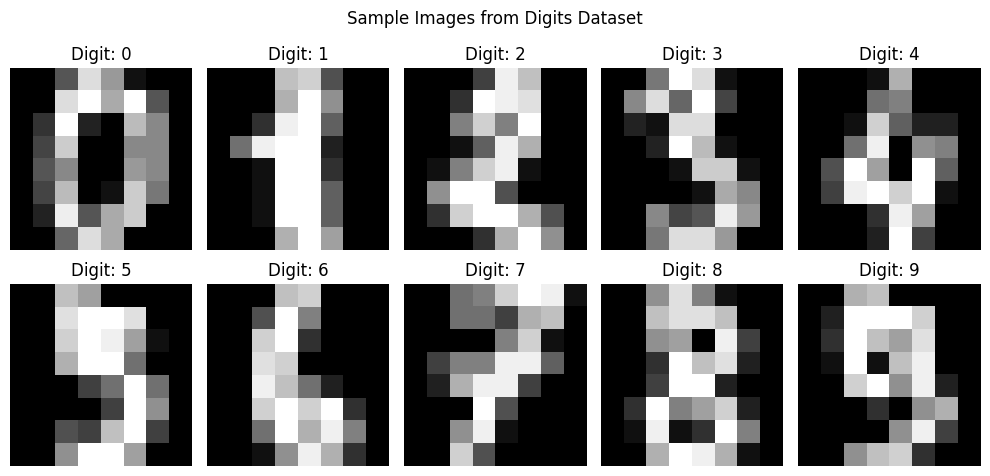


Training Samples: 1437
Testing Samples: 360

Model: Multi-Layer Perceptron Neural Network
Model Training Completed.

Model Performance
-----------------
Accuracy: 98.06%

Classification Report
---------------------
              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.9444    0.9444    0.9444        36
           2     0.9459    1.0000    0.9722        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     1.0000    0.9730    0.9863        37
           6     1.0000    1.0000    1.0000        36
           7     1.0000    1.0000    1.0000        36
           8     0.9697    0.9143    0.9412        35
           9     0.9730    1.0000    0.9863        36

    accuracy                         0.9806       360
   macro avg     0.9806    0.9804    0.9803       360
weighted avg     0.9808    0.9806    0.9805       360



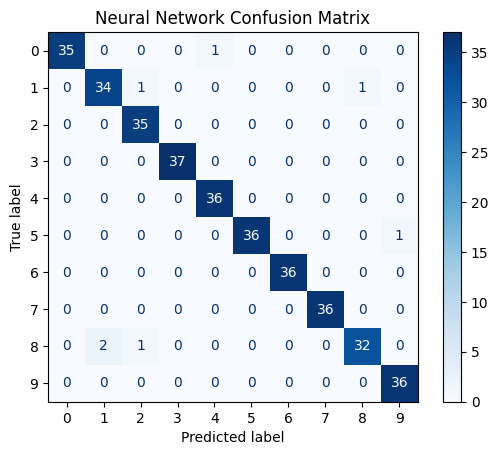

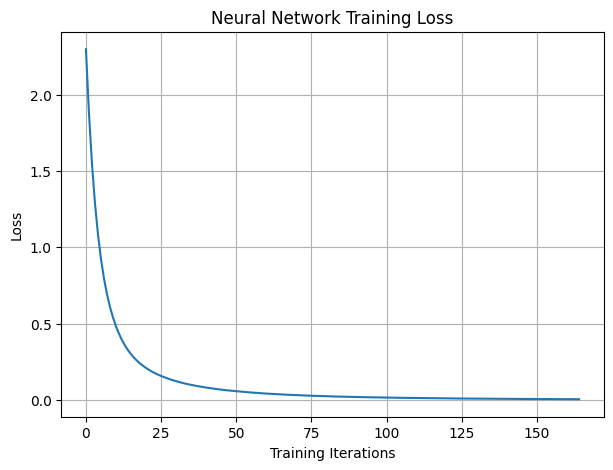


Sample Predictions
------------------
1. Actual: 5 | Predicted: 5
2. Actual: 2 | Predicted: 2
3. Actual: 8 | Predicted: 8
4. Actual: 1 | Predicted: 8
5. Actual: 7 | Predicted: 7

Task 1 Completed.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

digits = load_digits()

X = digits.data
y = digits.target

print("Dataset: Digits Dataset")
print("Total Samples:", len(X))
print("Features:", X.shape[1])
print("Classes:", np.unique(y))
print("Image Size: 8 x 8")

print("\nFirst 5 Samples")
print("----------------")

for i in range(5):
    print(
        f"{i + 1}. Label: {y[i]} | "
        f"Pixel Values: {X[i][:8]}"
    )

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.suptitle("Sample Images from Digits Dataset")
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "neural_network",
        MLPClassifier(
            hidden_layer_sizes=(64,),
            activation="relu",
            solver="adam",
            max_iter=300,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("\nModel: Multi-Layer Perceptron Neural Network")
print("Model Training Completed.")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report")
print("---------------------")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=digits.target_names
).plot(cmap="Blues")

plt.title("Neural Network Confusion Matrix")
plt.show()

mlp = model.named_steps["neural_network"]

plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_)
plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss")
plt.grid()
plt.show()

print("\nSample Predictions")
print("------------------")

for i in range(5):
    print(
        f"{i + 1}. Actual: {y_test[i]} | "
        f"Predicted: {y_pred[i]}"
    )

print("\nTask 1 Completed.")

**Task 2 — ML: Classification Model**

i have used the Breast Cancer Wisconsin dataset built into Scikit-learn.

This gives a different classification problem and allows us to show a proper classification workflow.

Dataset: Breast Cancer Wisconsin Dataset
Total Samples: 569
Features: 30
Classes: ['malignant' 'benign']

First 5 Samples
----------------
1. Class: malignant | First 5 Features: [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01]
2. Class: malignant | First 5 Features: [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02]
3. Class: malignant | First 5 Features: [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01]
4. Class: malignant | First 5 Features: [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01]
5. Class: malignant | First 5 Features: [2.029e+01 1.434e+01 1.351e+02 1.297e+03 1.003e-01]


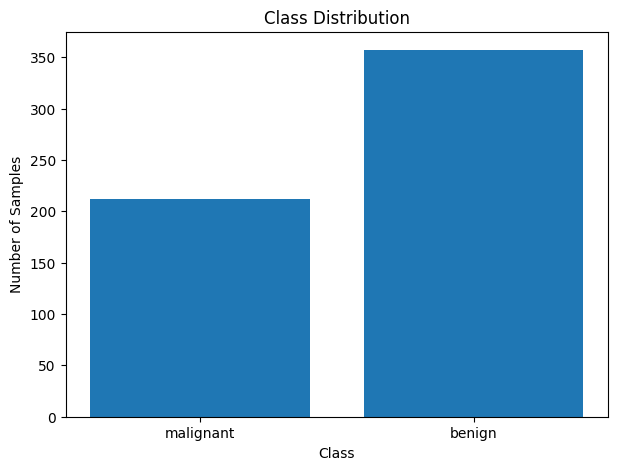


Training Samples: 455
Testing Samples: 114

Model: Logistic Regression
Model Training Completed.

Model Performance
-----------------
Accuracy: 98.25%

Classification Report
---------------------
              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



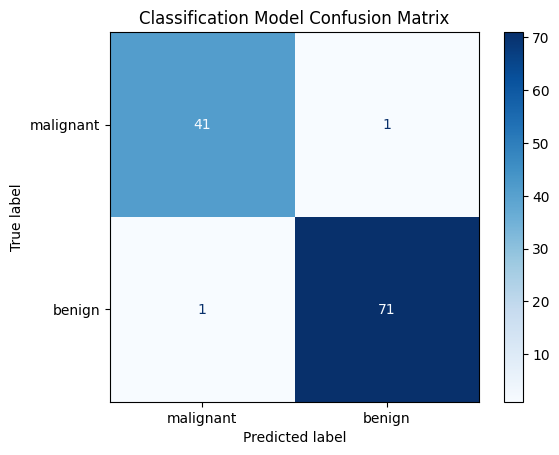

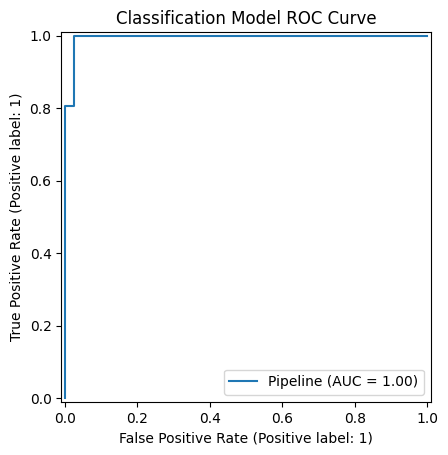


Sample Predictions
------------------
1. Actual: malignant | Predicted: malignant
2. Actual: benign | Predicted: benign
3. Actual: malignant | Predicted: malignant
4. Actual: benign | Predicted: benign
5. Actual: malignant | Predicted: malignant

Task 2 Completed.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("Dataset: Breast Cancer Wisconsin Dataset")
print("Total Samples:", len(X))
print("Features:", X.shape[1])
print("Classes:", cancer.target_names)

print("\nFirst 5 Samples")
print("----------------")

for i in range(5):
    print(
        f"{i + 1}. Class: {cancer.target_names[y[i]]} | "
        f"First 5 Features: {X[i][:5]}"
    )

class_counts = np.bincount(y)

plt.figure(figsize=(7, 5))

plt.bar(
    cancer.target_names,
    class_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=500,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("\nModel: Logistic Regression")
print("Model Training Completed.")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report")
print("---------------------")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=cancer.target_names,
        digits=4
    )
)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
).plot(cmap="Blues")

plt.title("Classification Model Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Classification Model ROC Curve")
plt.show()

print("\nSample Predictions")
print("------------------")

for i in range(5):
    print(
        f"{i + 1}. Actual: {cancer.target_names[y_test[i]]} | "
        f"Predicted: {cancer.target_names[y_pred[i]]}"
    )

print("\nTask 2 Completed.")